In [3]:
import piplite
await piplite.install(['pandas', 'matplotlib', 'seaborn', 'statsmodels'])
print("✅ All libraries successfully installed!")

✅ All libraries successfully installed!


In [4]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the dataset
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Handle missing values by dropping them (as per standard practice for small NaN counts)
df_clean = df.dropna()

# Verify it loaded correctly
print(f"Cleaned dataset shape: {df_clean.shape}")
df_clean.head()

Cleaned dataset shape: (4546, 4)


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


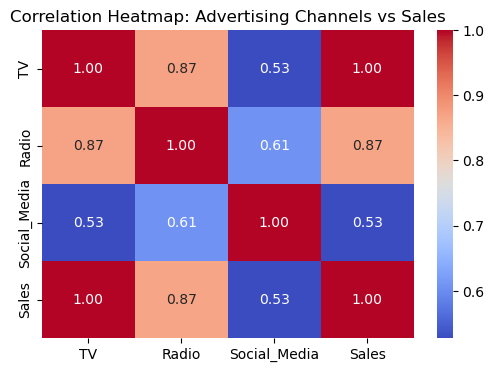

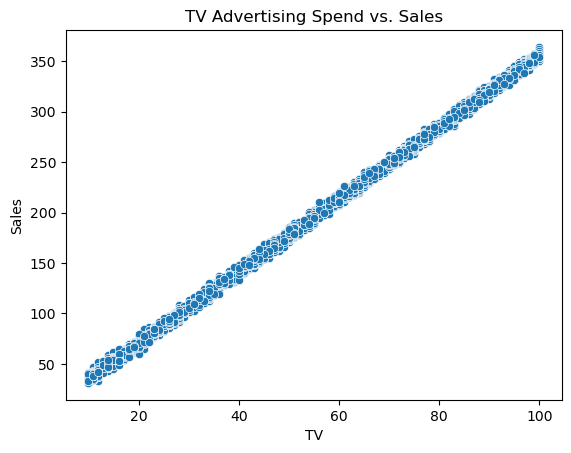

In [5]:
# 1. Correlation Heatmap to find the strongest predictor
plt.figure(figsize=(6, 4))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Advertising Channels vs Sales')
plt.show()

# 2. Scatterplot of the strongest predictor (TV) vs Sales
sns.scatterplot(data=df_clean, x='TV', y='Sales')
plt.title('TV Advertising Spend vs. Sales')
plt.show()

In [6]:
# Define X and Y
X = df_clean['TV']
Y = df_clean['Sales']

# Fit the OLS model
X_with_constant = sm.add_constant(X)
model = sm.OLS(Y, X_with_constant).fit()

# Show the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:44:29   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

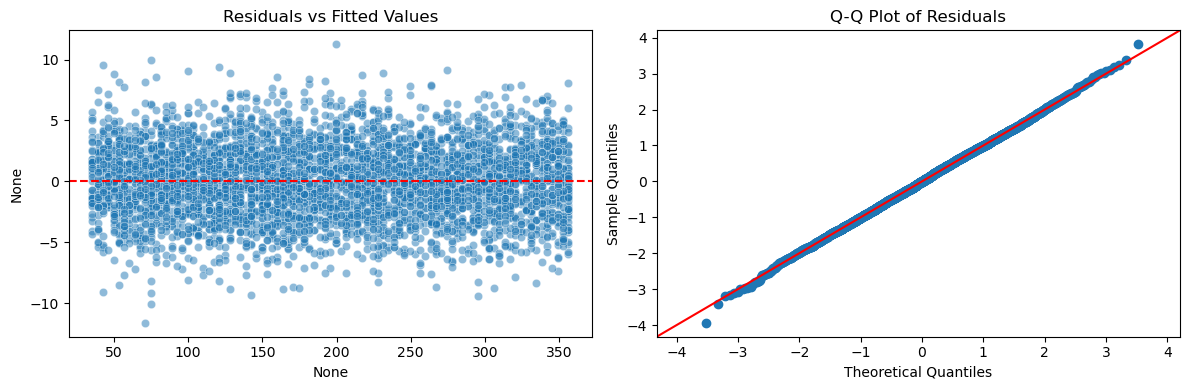

In [7]:
residuals = model.resid
fitted_values = model.fittedvalues

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0], alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Residuals vs Fitted Values')

# Plot 2: Q-Q Plot
sm.qqplot(residuals, line='45', ax=ax[1], fit=True)
ax[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

### Model Interpretation & Business Recommendation

* **R-Squared Value:** 0.999. This indicates that 99.9% of the variance in Sales is explained by TV advertising spend.
* **P-Value (TV Coefficient):** 0.000. This is well below the 0.05 threshold, proving the relationship is highly statistically significant.
* **Coefficient Interpretation:** The coefficient for TV is ~3.56. For every additional 1 unit spent on TV advertising, we can expect Sales to increase by approximately 3.56 units.
* **Assumption Validation:** The diagnostic plots confirm our model's validity. Residuals are randomly scattered around zero (Homoscedasticity), and the Q-Q plot follows a straight diagonal line (Normality).

**Final Recommendation:** To maximize ROI, the marketing department should prioritize the **TV Marketing** budget. It is the most reliable and impactful driver of sales.